# **Deep Learning Lab: Transfer Learning**

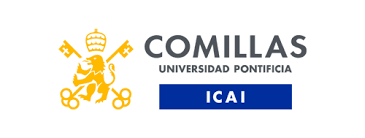

***

In [ ]:
!cat /proc/cpuinfo

processor	: 0
vendor_id	: GenuineIntel
cpu family	: 6
model		: 85
model name	: Intel(R) Xeon(R) CPU @ 2.00GHz
stepping	: 3
microcode	: 0xffffffff
cpu MHz		: 2000.160
cache size	: 39424 KB
physical id	: 0
siblings	: 2
core id		: 0
cpu cores	: 1
apicid		: 0
initial apicid	: 0
fpu		: yes
fpu_exception	: yes
cpuid level	: 13
wp		: yes
flags		: fpu vme de pse tsc msr pae mce cx8 apic sep mtrr pge mca cmov pat pse36 clflush mmx fxsr sse sse2 ss ht syscall nx pdpe1gb rdtscp lm constant_tsc rep_good nopl xtopology nonstop_tsc cpuid tsc_known_freq pni pclmulqdq ssse3 fma cx16 pcid sse4_1 sse4_2 x2apic movbe popcnt aes xsave avx f16c rdrand hypervisor lahf_lm abm 3dnowprefetch invpcid_single ssbd ibrs ibpb stibp fsgsbase tsc_adjust bmi1 hle avx2 smep bmi2 erms invpcid rtm mpx avx512f avx512dq rdseed adx smap clflushopt clwb avx512cd avx512bw avx512vl xsaveopt xsavec xgetbv1 xsaves arat md_clear arch_capabilities
bugs		: cpu_meltdown spectre_v1 spectre_v2 spec_store_bypass l1tf mds swapgs taa mmi

In [ ]:
!ln -sf /opt/bin/nvidia-smi /usr/bin/nvidia-smi
!nvidia-smi

Tue Apr 15 09:37:37 2025       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 550.54.15              Driver Version: 550.54.15      CUDA Version: 12.4     |
|-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   51C    P8             10W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [ ]:
import tensorflow as tf

# Check GPU availability
print("GPU Available:", tf.test.is_gpu_available())

# Check TPU availability
tpu_available = False
devices = tf.config.list_logical_devices()
for device in devices:
    if device.device_type == 'TPU':
        tpu_available = True
        break

print("TPU Available:", tpu_available)

Instructions for updating:
Use `tf.config.list_physical_devices('GPU')` instead.


GPU Available: True
TPU Available: False


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

# Navigate to code directory
%cd /content/drive/My Drive/Google Colab#/03TransferLearning

# List project directory contents
!ls

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
[Errno 2] No such file or directory: '/content/drive/My Drive/Google Colab#/03TransferLearning'
/content
best_finetuned.pth		   efficientnet_b0_two_phase.pth
best_finetuned_with_train_acc.pth  final_finetuned_with_train_acc.pth
best_one_phase_lr_diff.pth	   final_one_phase_lr_diff.pth
best_one_phase_tuned.pth	   final_one_phase_tuned.pth
best_phase1.pth			   sample_data
best_phase2.pth			   wandb
drive


## Import packages

In [ ]:
from importlib import reload  # Allows reloading user libraries
import sys
sys.path.append('/content/drive/My Drive/deep_learning_lab')
import cnn
from cnn import CNN
import torchvision
from cnn import load_data
from cnn import load_model_weights
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
import numpy as np
import os
import json
reload(cnn)

<module 'cnn' from '/content/drive/My Drive/deep_learning_lab/cnn.py'>

## Model and data loading

In [ ]:
# Pytorch has many pre-trained models that can be used for transfer learning
classification_models = torchvision.models.list_models(module=torchvision.models)
print(classification_models)

['alexnet', 'convnext_base', 'convnext_large', 'convnext_small', 'convnext_tiny', 'densenet121', 'densenet161', 'densenet169', 'densenet201', 'efficientnet_b0', 'efficientnet_b1', 'efficientnet_b2', 'efficientnet_b3', 'efficientnet_b4', 'efficientnet_b5', 'efficientnet_b6', 'efficientnet_b7', 'efficientnet_v2_l', 'efficientnet_v2_m', 'efficientnet_v2_s', 'googlenet', 'inception_v3', 'maxvit_t', 'mnasnet0_5', 'mnasnet0_75', 'mnasnet1_0', 'mnasnet1_3', 'mobilenet_v2', 'mobilenet_v3_large', 'mobilenet_v3_small', 'regnet_x_16gf', 'regnet_x_1_6gf', 'regnet_x_32gf', 'regnet_x_3_2gf', 'regnet_x_400mf', 'regnet_x_800mf', 'regnet_x_8gf', 'regnet_y_128gf', 'regnet_y_16gf', 'regnet_y_1_6gf', 'regnet_y_32gf', 'regnet_y_3_2gf', 'regnet_y_400mf', 'regnet_y_800mf', 'regnet_y_8gf', 'resnet101', 'resnet152', 'resnet18', 'resnet34', 'resnet50', 'resnext101_32x8d', 'resnext101_64x4d', 'resnext50_32x4d', 'shufflenet_v2_x0_5', 'shufflenet_v2_x1_0', 'shufflenet_v2_x1_5', 'shufflenet_v2_x2_0', 'squeezenet1_0

In [ ]:
train_dir = '/content/drive/My Drive/deep_learning_lab/dataset/training'
valid_dir = '/content/drive/My Drive/deep_learning_lab/dataset/validation'

train_loader, valid_loader, num_classes = load_data(train_dir,
                                                    valid_dir,
                                                    batch_size=32,
                                                    img_size=224) # EfficientNet_B0: 224x224

# Cargamos ResNet18 y lo pasamos a la clase CNN actualizada
# model = CNN(torchvision.models.resnet18(weights='DEFAULT'), num_classes)

# Usamos EfficientNet_B0 en lugar de ResNet18
import torch.nn as nn

model = torchvision.models.efficientnet_b0(weights='DEFAULT')
# Reemplazamos la última capa para que tenga num_classes salidas.
in_features = model.classifier[1].in_features
model.classifier[1] = nn.Linear(in_features, num_classes)
# Luego pasamos el modelo a nuestro wrapper CNN si es necesario:
model = CNN(model, num_classes)


AttributeError: 'EfficientNet' object has no attribute 'fc'

In [ ]:
# Load data and model
train_dir = '/content/drive/My Drive/deep_learning_lab/dataset/training'
valid_dir = '/content/drive/My Drive/deep_learning_lab/dataset/validation'

train_loader, valid_loader, num_classes = load_data(train_dir,
                                                    valid_dir,
                                                    batch_size=32,
                                                    img_size=224) # ResNet50 requires 224x224 images
# Remove classifier_attr, or modify cnn.py to include this argument in the CNN class's __init__ method
# model = CNN(torchvision.models.resnet18(weights='DEFAULT'), num_classes)
# aqui se cambia el modelo

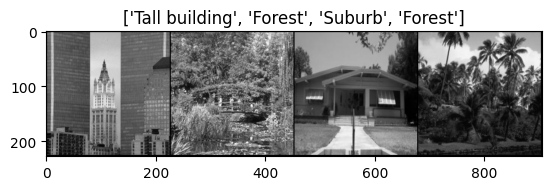

In [ ]:
# Visualize a few images
def imshow(inp, title=None):
    """Imshow for Tensor."""
    inp = inp.numpy().transpose((1, 2, 0))
    inp = np.clip(inp, 0, 1)
    plt.imshow(inp)
    if title is not None:
        plt.title(title)
    plt.pause(0.001)  # pause a bit so that plots are updated

# Get a few random images
random_indices = np.random.choice(len(valid_loader.dataset), size=4, replace=False)
inputs = []
classes = []
for i in random_indices:
    inputs.append(valid_loader.dataset[i][0])
    classes.append(valid_loader.dataset[i][1])
out = torchvision.utils.make_grid(inputs)
classnames = train_loader.dataset.classes
imshow(out, title=[classnames[x] for x in classes])

## Train

In [ ]:
optimizer = torch.optim.Adam(model.parameters(), lr=1e-4)
criterion = nn.CrossEntropyLoss()
history = model.train_model(train_loader, valid_loader, optimizer, criterion, epochs=20)

KeyboardInterrupt: 

In [ ]:
model.save_model('resnet18-1epoch')

## Predict

#### Load model

In [ ]:
# Load model
# model_weights = load_model_weights('resnet18-1epoch') ## cambiar modelo
# my_trained_model = CNN(torchvision.models.resnet18(weights='DEFAULT'), num_classes)
# my_trained_model.load_state_dict(model_weights)

model_weights = load_model_weights('efficientnetb0-1epoch')  ## nombre actualizado de los pesos
my_trained_model = CNN(torchvision.models.efficientnet_b0(weights='DEFAULT'), num_classes)
# Si fuera necesario, también modifica la capa final para ajustarla al número de clases
in_features = my_trained_model.model.classifier[1].in_features  # Esto asume que en CNN guardas el modelo en un atributo .model
my_trained_model.model.classifier[1] = nn.Linear(in_features, num_classes)
my_trained_model.load_state_dict(model_weights)


NameError: name 'load_model_weights' is not defined

## Results

In [ ]:
predicted_labels = my_trained_model.predict(valid_loader)

In [ ]:
# Get a few random images
random_indices = np.random.choice(len(valid_loader.dataset), size=4, replace=False)
inputs = []
classes = []
for i in random_indices:
    inputs.append(valid_loader.dataset[i][0])
    classes.append(predicted_labels[i])

out = torchvision.utils.make_grid(inputs)
classnames = train_loader.dataset.classes
imshow(out, title=[classnames[x] for x in classes])


# Efficient net

ENTENAMIENTO DOS FASES: efficientnet_b0_two_phase_unfreeze3

In [ ]:
# ─── Cell 1: Autenticación W&B ──────────────────────────────
import wandb
wandb.login()  # Ejecuta esto primero para no bloquear el training


True

In [ ]:
# ─── Cell 2: Inicializar experimento y configurar hyperparámetros ───────────
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms
from torchvision.models import efficientnet_b0, EfficientNet_B0_Weights

# Inicializar W&B
import wandb
wandb.init(
    entity="guillaume_-universidad-pontificia-comillas",
    project="machine_learning_II_CNN",
    name="efficientnet_b0_two_phase_unfreeze3"
)

# Configuración de hyperparámetros en W&B
config = wandb.config
config.batch_size           = 32
config.lr_phase1            = 0.001
config.epochs_phase1        = 5
config.lr_phase2            = 0.0001
config.epochs_phase2        = 5
config.unfreezed_layers     = 3
config.scheduler_step1      = 4
config.scheduler_gamma1     = 0.1
config.scheduler_step2      = 3
config.scheduler_gamma2     = 0.1


In [ ]:
# ─── Cell 3: Transformaciones y DataLoaders ────────────────────────────
train_dir = '/content/drive/My Drive/deep_learning_lab/dataset/training'
valid_dir = '/content/drive/My Drive/deep_learning_lab/dataset/validation'

train_transforms = transforms.Compose([
    transforms.Resize(256),
    transforms.RandomResizedCrop(224),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(15),
    transforms.ColorJitter(0.2,0.2,0.2,0.1),
    transforms.ToTensor(),
    transforms.Normalize([0.485,0.456,0.406],[0.229,0.224,0.225])
])
valid_transforms = transforms.Compose([
    transforms.Resize(256),
    transforms.CenterCrop(224),
    transforms.ToTensor(),
    transforms.Normalize([0.485,0.456,0.406],[0.229,0.224,0.225])
])

train_dataset = datasets.ImageFolder(train_dir, transform=train_transforms)
valid_dataset = datasets.ImageFolder(valid_dir, transform=valid_transforms)
config.num_classes = len(train_dataset.classes)

train_loader = torch.utils.data.DataLoader(
    train_dataset, batch_size=config.batch_size, shuffle=True, num_workers=2)
valid_loader = torch.utils.data.DataLoader(
    valid_dataset, batch_size=config.batch_size, shuffle=False, num_workers=2)

print("Clases:", train_dataset.classes)
print("# train:", len(train_dataset), "# val:", len(valid_dataset))


Clases: ['Bedroom', 'Coast', 'Forest', 'Highway', 'Industrial', 'Inside city', 'Kitchen', 'Living room', 'Mountain', 'Office', 'Open country', 'Store', 'Street', 'Suburb', 'Tall building']
# train: 2985 # val: 1500


In [ ]:
# ─── Cell 4: Cargar y preparar el modelo ────────────────────────────────
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = efficientnet_b0(weights=EfficientNet_B0_Weights.IMAGENET1K_V1)

# Fase 1: congelar toda la base
for p in model.parameters():
    p.requires_grad = False

# Descongelar últimas `config.unfreezed_layers` capas de model.features
total = len(model.features)
for idx in range(total - config.unfreezed_layers, total):
    for p in model.features[idx].parameters():
        p.requires_grad = True

# Reemplazar classifier para nuestro número de clases
num_feats = model.classifier[1].in_features
model.classifier[1] = nn.Linear(num_feats, config.num_classes)

model = model.to(device)


In [ ]:
# ─── Cell 5: Configurar W&B watch y criterio ────────────────────────────
# No loggearemos weights/gradients para reducir overhead
wandb.watch(model, log=None)

criterion = nn.CrossEntropyLoss()


In [ ]:
# ─── Cell 6: Optimizers y schedulers para ambas fases ───────────────────
# Fase 1
optimizer1 = optim.Adam(
    filter(lambda p: p.requires_grad, model.parameters()),
    lr=config.lr_phase1)
scheduler1 = optim.lr_scheduler.StepLR(
    optimizer1,
    step_size=config.scheduler_step1,
    gamma=config.scheduler_gamma1)

# Fase 2 (se creará más abajo, tras completar fase 1)


In [ ]:
# ─── Cell 7: Bucle de entrenamiento Fase 1 ───────────────────────────────
best_acc = 0.0

for epoch in range(config.epochs_phase1):
    model.train()
    total_loss = 0.0
    for imgs, labels in train_loader:
        imgs, labels = imgs.to(device), labels.to(device)
        optimizer1.zero_grad()
        outs = model(imgs)
        loss = criterion(outs, labels)
        loss.backward()
        optimizer1.step()
        total_loss += loss.item() * imgs.size(0)
    train_loss = total_loss / len(train_dataset)

    # Validación
    model.eval()
    correct = total = 0
    with torch.no_grad():
        for imgs, labels in valid_loader:
            imgs, labels = imgs.to(device), labels.to(device)
            outs = model(imgs)
            _, preds = outs.max(1)
            total += labels.size(0)
            correct += (preds == labels).sum().item()
    val_acc = 100 * correct / total

    scheduler1.step()

    wandb.log({
        "phase": "phase1",
        "epoch": epoch+1,
        "train_loss": train_loss,
        "valid_accuracy": val_acc,
        "lr": optimizer1.param_groups[0]['lr']
    })

    if val_acc > best_acc:
        best_acc = val_acc
        torch.save(model.state_dict(), 'best_phase1.pth')


In [ ]:
# ─── Cell 8: Preparar y ejecutar Fase 2 ─────────────────────────────────
# Descongelar TODO el modelo
for p in model.parameters():
    p.requires_grad = True

optimizer2 = optim.Adam(model.parameters(), lr=config.lr_phase2)
scheduler2 = optim.lr_scheduler.StepLR(
    optimizer2,
    step_size=config.scheduler_step2,
    gamma=config.scheduler_gamma2)

for epoch in range(config.epochs_phase2):
    model.train()
    total_loss = 0.0
    for imgs, labels in train_loader:
        imgs, labels = imgs.to(device), labels.to(device)
        optimizer2.zero_grad()
        outs = model(imgs)
        loss = criterion(outs, labels)
        loss.backward()
        optimizer2.step()
        total_loss += loss.item() * imgs.size(0)
    train_loss = total_loss / len(train_dataset)

    # Validación
    model.eval()
    correct = total = 0
    with torch.no_grad():
        for imgs, labels in valid_loader:
            imgs, labels = imgs.to(device), labels.to(device)
            outs = model(imgs)
            _, preds = outs.max(1)
            total += labels.size(0)
            correct += (preds == labels).sum().item()
    val_acc = 100 * correct / total

    scheduler2.step()

    wandb.log({
        "phase": "phase2",
        "epoch": epoch+1,
        "train_loss": train_loss,
        "valid_accuracy": val_acc,
        "lr": optimizer2.param_groups[0]['lr']
    })

    if val_acc > best_acc:
        best_acc = val_acc
        torch.save(model.state_dict(), 'best_phase2.pth')


In [ ]:
# ─── Cell 9: Guardar modelo final y cerrar W&B ──────────────────────────
torch.save(model.state_dict(), 'efficientnet_b0_two_phase.pth')
print(f"Mejor Accuracy obtenido: {best_acc:.2f}%")
wandb.finish()


Mejor Accuracy obtenido: 93.47%


epoch,▁▃▅▆█▁▃▅▆█
lr,███▂▂▂▂▁▁▁
train_loss,█▄▄▃▂▂▂▁▁▁
valid_accuracy,▁▄▁▆▆▇████
epoch,5
lr,1e-05
phase,phase2
train_loss,0.28412
valid_accuracy,92.86667


ENTRENAMIENTO efficientnet_b0 (unfreezed5)





In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms
from torchvision.models import efficientnet_b0, EfficientNet_B0_Weights
import wandb

# (1) Inicializa W&B (suponiendo ya has corrido wandb.login() en otra celda)
wandb.init(
    entity="guillaume_-universidad-pontificia-comillas",
    project="machine_learning_II_CNN",
    name="efficientnet_b0"
)

# (2) Hiperparámetros
config = wandb.config
config.batch_size       = 32
config.lr               = 1e-5
config.epochs           = 20
config.unfreezed_layers = 5  # prueba 3, 5, 10...

# (3) Datasets y DataLoaders
train_dir = '/content/drive/My Drive/deep_learning_lab/dataset/training'
valid_dir = '/content/drive/My Drive/deep_learning_lab/dataset/validation'

train_tf = transforms.Compose([
    transforms.Resize(256),
    transforms.RandomResizedCrop(224),
    transforms.RandomHorizontalFlip(),
    transforms.ColorJitter(0.2,0.2,0.2,0.1),
    transforms.ToTensor(),
    transforms.Normalize([0.485,0.456,0.406],[0.229,0.224,0.225])
])
valid_tf = transforms.Compose([
    transforms.Resize(256),
    transforms.CenterCrop(224),
    transforms.ToTensor(),
    transforms.Normalize([0.485,0.456,0.406],[0.229,0.224,0.225])
])

train_ds = datasets.ImageFolder(train_dir, transform=train_tf)
valid_ds = datasets.ImageFolder(valid_dir, transform=valid_tf)
config.num_classes = len(train_ds.classes)

train_loader = torch.utils.data.DataLoader(train_ds, batch_size=config.batch_size, shuffle=True, num_workers=2)
valid_loader = torch.utils.data.DataLoader(valid_ds, batch_size=config.batch_size, shuffle=False, num_workers=2)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# (4) Modelo y descongelado parcial
model = efficientnet_b0(weights=EfficientNet_B0_Weights.IMAGENET1K_V1)
# congela todo
for p in model.parameters():
    p.requires_grad = False
# descongela últimas N capas
total = len(model.features)
for idx in range(total - config.unfreezed_layers, total):
    for p in model.features[idx].parameters():
        p.requires_grad = True
# reemplaza classifier
in_feats = model.classifier[1].in_features
model.classifier[1] = nn.Linear(in_feats, config.num_classes)
model = model.to(device)

# (5) W&B watch y loss
wandb.watch(model, log=None)
criterion = nn.CrossEntropyLoss()

# (6) Optimizer + Scheduler
optimizer = optim.Adam(filter(lambda p: p.requires_grad, model.parameters()), lr=config.lr)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer,
                                                 mode='min',
                                                 factor=0.2,
                                                 patience=3,
                                                 min_lr=1e-7)

best_acc = 0.0

# (7) Bucle único de fine-tuning con train_accuracy
for epoch in range(config.epochs):
    model.train()
    running_loss = 0.0
    train_correct = 0
    train_total = 0

    for imgs, labels in train_loader:
        imgs, labels = imgs.to(device), labels.to(device)
        optimizer.zero_grad()
        outs = model(imgs)
        loss = criterion(outs, labels)
        loss.backward()
        optimizer.step()

        # update loss and accuracy counters
        running_loss += loss.item() * imgs.size(0)
        preds = outs.argmax(1)
        train_correct += (preds == labels).sum().item()
        train_total += labels.size(0)

    train_loss = running_loss / len(train_ds)
    train_acc = 100 * train_correct / train_total

    # validación
    model.eval()
    valid_loss = 0.0
    valid_correct = 0
    valid_total = 0
    with torch.no_grad():
        for imgs, labels in valid_loader:
            imgs, labels = imgs.to(device), labels.to(device)
            outs = model(imgs)
            loss = criterion(outs, labels)
            valid_loss += loss.item() * imgs.size(0)
            preds = outs.argmax(1)
            valid_correct += (preds == labels).sum().item()
            valid_total += labels.size(0)

    valid_loss /= len(valid_ds)
    valid_acc = 100 * valid_correct / valid_total

    # scheduler step
    scheduler.step(valid_loss)

    # log a W&B incluyendo train_accuracy
    wandb.log({
        "epoch": epoch + 1,
        "train_loss": train_loss,
        "train_accuracy": train_acc,
        "valid_loss": valid_loss,
        "valid_accuracy": valid_acc,
        "learning_rate": optimizer.param_groups[0]['lr']
    })

    # guardar mejor
    if valid_acc > best_acc:
        best_acc = valid_acc
        torch.save(model.state_dict(), 'best_finetuned_with_train_acc.pth')

    print(f"Epoch {epoch+1}/{config.epochs} | "
          f"Train loss: {train_loss:.4f} | Train acc: {train_acc:.2f}% | "
          f"Val loss: {valid_loss:.4f} | Val acc: {valid_acc:.2f}%")

# (8) Cerrar
print(f"Mejor valid_accuracy: {best_acc:.2f}%")
torch.save(model.state_dict(), 'final_finetuned_with_train_acc.pth')
wandb.finish()


Epoch 1/20 | Train loss: 2.6574 | Train acc: 12.36% | Val loss: 2.5894 | Val acc: 19.40%


Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x7f622f83d940>
Traceback (most recent call last):
  File "/usr/local/lib/python3.11/dist-packages/torch/utils/data/dataloader.py", line 1618, in __del__
    self._shutdown_workers()
  File "/usr/local/lib/python3.11/dist-packages/torch/utils/data/dataloader.py", line 1601, in _shutdown_workers
    if w.is_alive():
       ^^^^^^^^^^^^
  File "/usr/lib/python3.11/multiprocessing/process.py", line 160, in is_alive
    assert self._parent_pid == os.getpid(), 'can only test a child process'
        Exception ignored in:  <function _MultiProcessingDataLoaderIter.__del__ at 0x7f622f83d940> 
 Traceback (most recent call last):
^  File "/usr/local/lib/python3.11/dist-packages/torch/utils/data/dataloader.py", line 1618, in __del__
^^    ^self._shutdown_workers()^
  File "/usr/local/lib/python3.11/dist-packages/torch/utils/data/dataloader.py", line 1601, in _shutdown_workers
^^    ^if w.is_alive():^
^ ^ ^ ^ ^^  ^^ ^^^^^^^^

Epoch 2/20 | Train loss: 2.5204 | Train acc: 25.53% | Val loss: 2.4495 | Val acc: 36.73%
Epoch 3/20 | Train loss: 2.3633 | Train acc: 40.47% | Val loss: 2.3132 | Val acc: 47.93%
Epoch 4/20 | Train loss: 2.1889 | Train acc: 51.46% | Val loss: 2.1190 | Val acc: 58.53%
Epoch 5/20 | Train loss: 1.9811 | Train acc: 59.26% | Val loss: 1.9158 | Val acc: 61.93%
Epoch 6/20 | Train loss: 1.7607 | Train acc: 66.26% | Val loss: 1.6873 | Val acc: 68.33%
Epoch 7/20 | Train loss: 1.5587 | Train acc: 68.27% | Val loss: 1.5013 | Val acc: 70.27%
Epoch 8/20 | Train loss: 1.3947 | Train acc: 70.55% | Val loss: 1.3231 | Val acc: 71.73%
Epoch 9/20 | Train loss: 1.2368 | Train acc: 72.63% | Val loss: 1.1511 | Val acc: 75.73%
Epoch 10/20 | Train loss: 1.1509 | Train acc: 72.83% | Val loss: 1.0807 | Val acc: 73.60%
Epoch 11/20 | Train loss: 1.0339 | Train acc: 75.31% | Val loss: 0.9541 | Val acc: 76.53%
Epoch 12/20 | Train loss: 0.9953 | Train acc: 73.53% | Val loss: 0.8406 | Val acc: 79.27%
Epoch 13/20 | Trai

epoch,▁▁▂▂▂▃▃▄▄▄▅▅▅▆▆▇▇▇██
learning_rate,▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
train_accuracy,▁▂▄▅▆▆▇▇▇▇▇▇█▇██████
train_loss,██▇▆▆▅▄▄▃▃▂▂▂▂▂▁▁▁▁▁
valid_accuracy,▁▃▄▅▅▆▆▆▇▇▇▇▇▇▇█████
valid_loss,██▇▆▆▅▄▄▃▃▃▂▂▂▂▂▁▁▁▁
epoch,20
learning_rate,1e-05
train_accuracy,82.21106
train_loss,0.62382
valid_accuracy,88.06667


ENTRENAMIENTO efficientnet_b0 (unfreezed3)


In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms
from torchvision.models import efficientnet_b0, EfficientNet_B0_Weights
import wandb

# (1) Inicializa W&B (suponiendo ya has corrido wandb.login() en otra celda)
wandb.init(
    entity="guillaume_-universidad-pontificia-comillas",
    project="machine_learning_II_CNN",
    name="efficientnet_b0_unfreeze3"
)

# (2) Hiperparámetros
config = wandb.config
config.batch_size       = 32
config.lr               = 1e-5
config.epochs           = 20
config.unfreezed_layers = 3  # prueba 3, 5, 10...

# (3) Datasets y DataLoaders
train_dir = '/content/drive/My Drive/deep_learning_lab/dataset/training'
valid_dir = '/content/drive/My Drive/deep_learning_lab/dataset/validation'

train_tf = transforms.Compose([
    transforms.Resize(256),
    transforms.RandomResizedCrop(224),
    transforms.RandomHorizontalFlip(),
    transforms.ColorJitter(0.2,0.2,0.2,0.1),
    transforms.ToTensor(),
    transforms.Normalize([0.485,0.456,0.406],[0.229,0.224,0.225])
])
valid_tf = transforms.Compose([
    transforms.Resize(256),
    transforms.CenterCrop(224),
    transforms.ToTensor(),
    transforms.Normalize([0.485,0.456,0.406],[0.229,0.224,0.225])
])

train_ds = datasets.ImageFolder(train_dir, transform=train_tf)
valid_ds = datasets.ImageFolder(valid_dir, transform=valid_tf)
config.num_classes = len(train_ds.classes)

train_loader = torch.utils.data.DataLoader(train_ds, batch_size=config.batch_size, shuffle=True, num_workers=2)
valid_loader = torch.utils.data.DataLoader(valid_ds, batch_size=config.batch_size, shuffle=False, num_workers=2)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# (4) Modelo y descongelado parcial
model = efficientnet_b0(weights=EfficientNet_B0_Weights.IMAGENET1K_V1)
# congela todo
for p in model.parameters():
    p.requires_grad = False
# descongela últimas N capas
total = len(model.features)
for idx in range(total - config.unfreezed_layers, total):
    for p in model.features[idx].parameters():
        p.requires_grad = True
# reemplaza classifier
in_feats = model.classifier[1].in_features
model.classifier[1] = nn.Linear(in_feats, config.num_classes)
model = model.to(device)

# (5) W&B watch y loss
wandb.watch(model, log=None)
criterion = nn.CrossEntropyLoss()

# (6) Optimizer + Scheduler
optimizer = optim.Adam(filter(lambda p: p.requires_grad, model.parameters()), lr=config.lr)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer,
                                                 mode='min',
                                                 factor=0.2,
                                                 patience=3,
                                                 min_lr=1e-7)

best_acc = 0.0

# (7) Bucle único de fine-tuning con train_accuracy
for epoch in range(config.epochs):
    model.train()
    running_loss = 0.0
    train_correct = 0
    train_total = 0

    for imgs, labels in train_loader:
        imgs, labels = imgs.to(device), labels.to(device)
        optimizer.zero_grad()
        outs = model(imgs)
        loss = criterion(outs, labels)
        loss.backward()
        optimizer.step()

        # update loss and accuracy counters
        running_loss += loss.item() * imgs.size(0)
        preds = outs.argmax(1)
        train_correct += (preds == labels).sum().item()
        train_total += labels.size(0)

    train_loss = running_loss / len(train_ds)
    train_acc = 100 * train_correct / train_total

    # validación
    model.eval()
    valid_loss = 0.0
    valid_correct = 0
    valid_total = 0
    with torch.no_grad():
        for imgs, labels in valid_loader:
            imgs, labels = imgs.to(device), labels.to(device)
            outs = model(imgs)
            loss = criterion(outs, labels)
            valid_loss += loss.item() * imgs.size(0)
            preds = outs.argmax(1)
            valid_correct += (preds == labels).sum().item()
            valid_total += labels.size(0)

    valid_loss /= len(valid_ds)
    valid_acc = 100 * valid_correct / valid_total

    # scheduler step
    scheduler.step(valid_loss)

    # log a W&B incluyendo train_accuracy
    wandb.log({
        "epoch": epoch + 1,
        "train_loss": train_loss,
        "train_accuracy": train_acc,
        "valid_loss": valid_loss,
        "valid_accuracy": valid_acc,
        "learning_rate": optimizer.param_groups[0]['lr']
    })

    # guardar mejor
    if valid_acc > best_acc:
        best_acc = valid_acc
        torch.save(model.state_dict(), 'best_finetuned_with_train_acc.pth')

    print(f"Epoch {epoch+1}/{config.epochs} | "
          f"Train loss: {train_loss:.4f} | Train acc: {train_acc:.2f}% | "
          f"Val loss: {valid_loss:.4f} | Val acc: {valid_acc:.2f}%")

# (8) Cerrar
print(f"Mejor valid_accuracy: {best_acc:.2f}%")
torch.save(model.state_dict(), 'final_finetuned_with_train_acc.pth')
wandb.finish()


Epoch 1/20 | Train loss: 2.6988 | Train acc: 8.68% | Val loss: 2.6243 | Val acc: 15.67%
Epoch 2/20 | Train loss: 2.5555 | Train acc: 22.55% | Val loss: 2.4874 | Val acc: 31.13%
Epoch 3/20 | Train loss: 2.4077 | Train acc: 35.71% | Val loss: 2.3551 | Val acc: 42.93%
Epoch 4/20 | Train loss: 2.2348 | Train acc: 46.37% | Val loss: 2.1710 | Val acc: 54.93%
Epoch 5/20 | Train loss: 2.0519 | Train acc: 51.99% | Val loss: 2.0122 | Val acc: 60.47%
Epoch 6/20 | Train loss: 1.8872 | Train acc: 57.92% | Val loss: 1.8564 | Val acc: 66.67%
Epoch 7/20 | Train loss: 1.7295 | Train acc: 61.41% | Val loss: 1.7168 | Val acc: 66.33%
Epoch 8/20 | Train loss: 1.6031 | Train acc: 64.72% | Val loss: 1.5804 | Val acc: 69.47%
Epoch 9/20 | Train loss: 1.4928 | Train acc: 66.73% | Val loss: 1.4302 | Val acc: 72.67%
Epoch 10/20 | Train loss: 1.3807 | Train acc: 68.84% | Val loss: 1.3559 | Val acc: 72.67%
Epoch 11/20 | Train loss: 1.2779 | Train acc: 70.89% | Val loss: 1.2150 | Val acc: 75.73%
Epoch 12/20 | Train 

epoch,▁▁▂▂▂▃▃▄▄▄▅▅▅▆▆▇▇▇██
learning_rate,▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
train_accuracy,▁▂▄▅▅▆▆▇▇▇▇▇▇▇██████
train_loss,█▇▇▆▆▅▅▄▄▃▃▃▂▂▂▂▁▁▁▁
valid_accuracy,▁▃▄▅▆▆▆▆▇▇▇▇▇▇▇█████
valid_loss,██▇▆▆▅▅▄▄▄▃▃▃▂▂▂▁▁▁▁
epoch,20
learning_rate,1e-05
train_accuracy,78.86097
train_loss,0.75532
valid_accuracy,84.73333


Probamos para mejorar el anterior

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms
from torchvision.models import efficientnet_b0, EfficientNet_B0_Weights
import wandb

# (1) Inicializa W&B (suponiendo ya has corrido wandb.login() en otra celda)
wandb.init(
    entity="guillaume_-universidad-pontificia-comillas",
    project="machine_learning_II_CNN",
    name="efficientnet_b0_unfreeze3_2"
)

# (2) Hiperparámetros
config = wandb.config
config.batch_size       = 32
config.lr_head          = 1e-4
config.lr_backbone      = 1e-5
config.epochs           = 20
config.unfreezed_layers = 3  # número de capas finales de backbone a descongelar

# (3) Datasets y DataLoaders
train_dir = '/content/drive/My Drive/deep_learning_lab/dataset/training'
valid_dir = '/content/drive/My Drive/deep_learning_lab/dataset/validation'

train_tf = transforms.Compose([
    transforms.Resize(256),
    transforms.RandomResizedCrop(224),
    transforms.RandomHorizontalFlip(),
    transforms.ColorJitter(0.2,0.2,0.2,0.1),
    transforms.ToTensor(),
    transforms.Normalize([0.485,0.456,0.406],[0.229,0.224,0.225])
])
valid_tf = transforms.Compose([
    transforms.Resize(256),
    transforms.CenterCrop(224),
    transforms.ToTensor(),
    transforms.Normalize([0.485,0.456,0.406],[0.229,0.224,0.225])
])

train_ds = datasets.ImageFolder(train_dir, transform=train_tf)
valid_ds = datasets.ImageFolder(valid_dir, transform=valid_tf)
config.num_classes = len(train_ds.classes)

train_loader = torch.utils.data.DataLoader(train_ds, batch_size=config.batch_size, shuffle=True, num_workers=2)
valid_loader = torch.utils.data.DataLoader(valid_ds, batch_size=config.batch_size, shuffle=False, num_workers=2)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# (4) Modelo y descongelado parcial
model = efficientnet_b0(weights=EfficientNet_B0_Weights.IMAGENET1K_V1)
# Freeze all backbone layers
for p in model.parameters():
    p.requires_grad = False

# Unfreeze last N layers of model.features
total = len(model.features)
for idx in range(total - config.unfreezed_layers, total):
    for p in model.features[idx].parameters():
        p.requires_grad = True

# Replace classifier for our number of classes
in_feats = model.classifier[1].in_features
model.classifier[1] = nn.Linear(in_feats, config.num_classes)
model = model.to(device)

# (5) W&B watch y función de pérdida
wandb.watch(model, log=None)
criterion = nn.CrossEntropyLoss()

# (6) Parámetros con lr diferencial
head_params = []
backbone_params = []
for name, p in model.named_parameters():
    if p.requires_grad:
        if "classifier" in name:
            head_params.append(p)
        else:
            backbone_params.append(p)

optimizer = optim.Adam([
    {"params": head_params,    "lr": config.lr_head},
    {"params": backbone_params,"lr": config.lr_backbone}
])
scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode='min', factor=0.2, patience=3, min_lr=1e-7
)

best_acc = 0.0

# (7) Bucle de entrenamiento
for epoch in range(config.epochs):
    model.train()
    running_loss = 0.0
    train_correct = 0
    train_total = 0

    for imgs, labels in train_loader:
        imgs, labels = imgs.to(device), labels.to(device)
        optimizer.zero_grad()
        outs = model(imgs)
        loss = criterion(outs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * imgs.size(0)
        preds = outs.argmax(1)
        train_correct += (preds == labels).sum().item()
        train_total += labels.size(0)

    train_loss = running_loss / len(train_ds)
    train_acc = 100 * train_correct / train_total

    # Validación
    model.eval()
    valid_loss = 0.0
    valid_correct = 0
    valid_total = 0
    with torch.no_grad():
        for imgs, labels in valid_loader:
            imgs, labels = imgs.to(device), labels.to(device)
            outs = model(imgs)
            loss = criterion(outs, labels)
            valid_loss += loss.item() * imgs.size(0)
            preds = outs.argmax(1)
            valid_correct += (preds == labels).sum().item()
            valid_total += labels.size(0)

    valid_loss /= len(valid_ds)
    valid_acc = 100 * valid_correct / valid_total

    # Scheduler step
    scheduler.step(valid_loss)

    # Log metrics en W&B
    wandb.log({
        "epoch": epoch + 1,
        "train_loss": train_loss,
        "train_accuracy": train_acc,
        "valid_loss": valid_loss,
        "valid_accuracy": valid_acc,
        "lr_head":    optimizer.param_groups[0]["lr"],
        "lr_backbone":optimizer.param_groups[1]["lr"]
    })

    # Guardar mejor modelo
    if valid_acc > best_acc:
        best_acc = valid_acc
        torch.save(model.state_dict(), 'best_one_phase_lr_diff.pth')

    print(f"Epoch {epoch+1}/{config.epochs} | "
          f"Train loss: {train_loss:.4f} | Train acc: {train_acc:.2f}% | "
          f"Val loss: {valid_loss:.4f} | Val acc: {valid_acc:.2f}%")

# (8) Guardar y finalizar
print(f"Mejor valid_accuracy: {best_acc:.2f}%")
torch.save(model.state_dict(), 'final_one_phase_lr_diff.pth')
wandb.finish()


Epoch 1/20 | Train loss: 2.5300 | Train acc: 22.65% | Val loss: 2.3490 | Val acc: 40.27%
Epoch 2/20 | Train loss: 2.1320 | Train acc: 48.61% | Val loss: 1.9565 | Val acc: 59.27%
Epoch 3/20 | Train loss: 1.7291 | Train acc: 63.58% | Val loss: 1.5873 | Val acc: 68.60%
Epoch 4/20 | Train loss: 1.4200 | Train acc: 69.55% | Val loss: 1.2954 | Val acc: 75.07%
Epoch 5/20 | Train loss: 1.2005 | Train acc: 71.36% | Val loss: 1.0780 | Val acc: 77.00%
Epoch 6/20 | Train loss: 1.0294 | Train acc: 75.34% | Val loss: 0.8830 | Val acc: 79.27%
Epoch 7/20 | Train loss: 0.8909 | Train acc: 76.88% | Val loss: 0.7590 | Val acc: 80.27%
Epoch 8/20 | Train loss: 0.7909 | Train acc: 78.19% | Val loss: 0.6444 | Val acc: 82.27%
Epoch 9/20 | Train loss: 0.7008 | Train acc: 80.74% | Val loss: 0.5578 | Val acc: 84.73%
Epoch 10/20 | Train loss: 0.6521 | Train acc: 81.61% | Val loss: 0.5358 | Val acc: 83.87%
Epoch 11/20 | Train loss: 0.6263 | Train acc: 81.47% | Val loss: 0.4743 | Val acc: 86.27%
Epoch 12/20 | Train

epoch,▁▁▂▂▂▃▃▄▄▄▅▅▅▆▆▇▇▇██
lr_backbone,▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
lr_head,▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
train_accuracy,▁▄▆▆▆▇▇▇▇█▇▇▇███████
train_loss,█▇▅▄▄▃▂▂▂▂▂▂▁▁▁▁▁▁▁▁
valid_accuracy,▁▄▅▆▆▆▇▇▇▇▇▇████████
valid_loss,█▇▅▄▄▃▃▂▂▂▂▂▁▁▁▁▁▁▁▁
epoch,20
lr_backbone,1e-05
lr_head,0.0001
train_accuracy,85.46064


unfreezed3_3

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms
from torchvision.models import efficientnet_b0, EfficientNet_B0_Weights
import wandb

# (1) Inicializa W&B (ejecuta wandb.login() en una celda previa)
wandb.init(
    entity="guillaume_-universidad-pontificia-comillas",
    project="machine_learning_II_CNN",
    name="efficientnet_b0_unfreezed3_3"
)

# (2) Hiperparámetros ajustados
config = wandb.config
config.batch_size       = 32
config.lr_head          = 1e-3   # lr mayor para la cabeza
config.lr_backbone      = 1e-4   # lr intermedia para el backbone
config.epochs           = 15
config.unfreezed_layers = 3      # últimas 3 capas de 'model.features' a descongelar

# (3) Datasets y DataLoaders
train_dir = '/content/drive/My Drive/deep_learning_lab/dataset/training'
valid_dir = '/content/drive/My Drive/deep_learning_lab/dataset/validation'

train_tf = transforms.Compose([
    transforms.Resize(256),
    transforms.RandomResizedCrop(224),
    transforms.RandomHorizontalFlip(),
    transforms.ColorJitter(0.2,0.2,0.2,0.1),
    transforms.ToTensor(),
    transforms.Normalize([0.485,0.456,0.406],[0.229,0.224,0.225])
])
valid_tf = transforms.Compose([
    transforms.Resize(256),
    transforms.CenterCrop(224),
    transforms.ToTensor(),
    transforms.Normalize([0.485,0.456,0.406],[0.229,0.224,0.225])
])

train_ds = datasets.ImageFolder(train_dir, transform=train_tf)
valid_ds = datasets.ImageFolder(valid_dir, transform=valid_tf)
config.num_classes = len(train_ds.classes)

train_loader = torch.utils.data.DataLoader(
    train_ds, batch_size=config.batch_size, shuffle=True, num_workers=2)
valid_loader = torch.utils.data.DataLoader(
    valid_ds, batch_size=config.batch_size, shuffle=False, num_workers=2)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# (4) Modelo y descongelado parcial
model = efficientnet_b0(weights=EfficientNet_B0_Weights.IMAGENET1K_V1)
# Congelar todo
for p in model.parameters():
    p.requires_grad = False
# Descongelar últimas N capas del backbone
total = len(model.features)
for idx in range(total - config.unfreezed_layers, total):
    for p in model.features[idx].parameters():
        p.requires_grad = True
# Reemplazar classifier para tu número de clases
in_feats = model.classifier[1].in_features
model.classifier[1] = nn.Linear(in_feats, config.num_classes)
model = model.to(device)

# (5) W&B watch y criterio
wandb.watch(model, log=None)
criterion = nn.CrossEntropyLoss()

# (6) Optimizer con lr diferencial y Scheduler
head_params = [p for n,p in model.named_parameters() if p.requires_grad and "classifier" in n]
backbone_params = [p for n,p in model.named_parameters() if p.requires_grad and "features" in n]

optimizer = optim.Adam([
    {"params": head_params,    "lr": config.lr_head},
    {"params": backbone_params,"lr": config.lr_backbone}
])
scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode='min', factor=0.2, patience=2, min_lr=1e-6
)

best_acc = 0.0

# (7) Bucle de entrenamiento
for epoch in range(config.epochs):
    model.train()
    running_loss = 0.0
    train_correct = train_total = 0

    for imgs, labels in train_loader:
        imgs, labels = imgs.to(device), labels.to(device)
        optimizer.zero_grad()
        outs = model(imgs)
        loss = criterion(outs, labels)
        loss.backward()
        optimizer.step()
        running_loss += loss.item() * imgs.size(0)
        preds = outs.argmax(1)
        train_correct += (preds == labels).sum().item()
        train_total += labels.size(0)

    train_loss = running_loss / train_total
    train_acc  = 100 * train_correct / train_total

    # Validación
    model.eval()
    valid_loss = valid_correct = valid_total = 0
    with torch.no_grad():
        for imgs, labels in valid_loader:
            imgs, labels = imgs.to(device), labels.to(device)
            outs = model(imgs)
            loss = criterion(outs, labels)
            valid_loss += loss.item() * imgs.size(0)
            preds = outs.argmax(1)
            valid_correct += (preds == labels).sum().item()
            valid_total += labels.size(0)

    valid_loss /= valid_total
    valid_acc  = 100 * valid_correct / valid_total

    # Scheduler y log
    scheduler.step(valid_loss)
    wandb.log({
        "epoch": epoch+1,
        "train_loss": train_loss,
        "train_accuracy": train_acc,
        "valid_loss": valid_loss,
        "valid_accuracy": valid_acc,
        "lr_head": optimizer.param_groups[0]["lr"],
        "lr_backbone": optimizer.param_groups[1]["lr"]
    })

    # Guardar mejor
    if valid_acc > best_acc:
        best_acc = valid_acc
        torch.save(model.state_dict(), 'best_one_phase_tuned.pth')

    print(f"Epoch {epoch+1}/{config.epochs} | "
          f"Train loss: {train_loss:.4f}, acc: {train_acc:.2f}% | "
          f"Val loss: {valid_loss:.4f}, acc: {valid_acc:.2f}%")

# (8) Guardar y cerrar
torch.save(model.state_dict(), 'final_one_phase_tuned.pth') ### Lo he llamado mal
print(f"Mejor valid_accuracy: {best_acc:.2f}%")
wandb.finish()


Epoch 1/15 | Train loss: 1.3904, acc: 60.60% | Val loss: 0.5344, acc: 85.40%
Epoch 2/15 | Train loss: 0.5678, acc: 81.57% | Val loss: 0.3495, acc: 88.87%
Epoch 3/15 | Train loss: 0.4713, acc: 84.66% | Val loss: 0.3166, acc: 90.00%
Epoch 4/15 | Train loss: 0.4246, acc: 86.37% | Val loss: 0.2733, acc: 90.87%
Epoch 5/15 | Train loss: 0.3821, acc: 87.17% | Val loss: 0.2475, acc: 91.80%
Epoch 6/15 | Train loss: 0.3463, acc: 88.64% | Val loss: 0.2717, acc: 90.93%
Epoch 7/15 | Train loss: 0.3233, acc: 89.78% | Val loss: 0.2433, acc: 91.67%
Epoch 8/15 | Train loss: 0.3162, acc: 89.18% | Val loss: 0.2543, acc: 91.67%
Epoch 9/15 | Train loss: 0.2822, acc: 91.49% | Val loss: 0.2601, acc: 91.00%
Epoch 10/15 | Train loss: 0.2791, acc: 90.42% | Val loss: 0.2260, acc: 91.73%
Epoch 11/15 | Train loss: 0.2845, acc: 89.98% | Val loss: 0.2395, acc: 91.47%
Epoch 12/15 | Train loss: 0.2589, acc: 91.62% | Val loss: 0.2673, acc: 91.13%
Epoch 13/15 | Train loss: 0.2456, acc: 92.13% | Val loss: 0.2350, acc: 92

epoch,▁▁▂▃▃▃▄▅▅▅▆▇▇▇█
lr_backbone,████████████▁▁▁
lr_head,████████████▁▁▁
train_accuracy,▁▅▆▇▇▇▇▇█▇▇████
train_loss,█▃▃▂▂▂▂▂▁▁▁▁▁▁▁
valid_accuracy,▁▄▆▆▇▇▇▇▇▇▇▇██▇
valid_loss,█▄▃▂▁▂▁▂▂▁▁▂▁▁▂
epoch,15
lr_backbone,2e-05
lr_head,0.0002
train_accuracy,93.23283


In [44]:
# ─── Cell: Inferencia sobre tus 5 imágenes de test ─────────────────────────

import torch
import torch.nn as nn
from PIL import Image
import os, glob
from torchvision import transforms as T, datasets
from torchvision.models import efficientnet_b0, EfficientNet_B0_Weights

# 1) Montar Drive (solo si no lo has hecho en esta sesión)
from google.colab import drive
drive.mount('/content/drive', force_remount=True)

# 2) Rutas
test_dir   = "/content/drive/MyDrive/deep_learning_lab/dataset/test"
train_dir  = "/content/drive/MyDrive/deep_learning_lab/dataset/training"
model_path = "final_one_phase_tuned.pth"
# Ajusta la carpeta donde guardaste tu .pth si es distinta

# 3) Comprueba que existen
assert os.path.isdir(test_dir),  f"No existe {test_dir}"
assert os.path.isdir(train_dir), f"No existe {train_dir}"
assert os.path.isfile(model_path), f"No existe {model_path}"

# 4) Lista todos los JPG de test
image_paths = glob.glob(os.path.join(test_dir, "*.jpg"))
print(f"Encontradas {len(image_paths)} imágenes de test:", image_paths)

# 5) Transform de inferencia (convierte a gris 3 canales, resize, tensor y normaliza)
infer_transform = T.Compose([
    T.Grayscale(num_output_channels=3),
    T.Resize((224, 224)),
    T.ToTensor(),
    T.Normalize([0.485,0.456,0.406],
                [0.229,0.224,0.225])
])

# 6) Carga nombres de clase desde tu carpeta de entrenamiento
train_ds = datasets.ImageFolder(train_dir, transform=infer_transform)
class_names = train_ds.classes

# 7) Reconstruye el modelo y carga pesos
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = efficientnet_b0(weights=None)
in_feats = model.classifier[1].in_features
model.classifier[1] = nn.Linear(in_feats, len(class_names))
model.load_state_dict(torch.load(model_path, map_location=device))
model.to(device).eval()

# 8) Haz la inferencia y muestra las predicciones
for img_path in sorted(image_paths):
    img = Image.open(img_path).convert("RGB")
    inp = infer_transform(img).unsqueeze(0).to(device)
    with torch.no_grad():
        out = model(inp)
    pred = out.argmax(1).item()
    print(f"{os.path.basename(img_path)} → {class_names[pred]}")


Mounted at /content/drive
Encontradas 5 imágenes de test: ['/content/drive/MyDrive/deep_learning_lab/dataset/test/kitchen.jpg', '/content/drive/MyDrive/deep_learning_lab/dataset/test/Industrial.jpg', '/content/drive/MyDrive/deep_learning_lab/dataset/test/Living room.jpg', '/content/drive/MyDrive/deep_learning_lab/dataset/test/Coast.jpg', '/content/drive/MyDrive/deep_learning_lab/dataset/test/Bedroom.jpg']
Bedroom.jpg → Bedroom
Coast.jpg → Coast
Industrial.jpg → Tall building
Living room.jpg → Bedroom
kitchen.jpg → Kitchen


In [ ]:
# Importar librerías necesarias
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms, models
from torchvision.models import efficientnet_b0, EfficientNet_B0_Weights
import os

# Definir las rutas a los directorios de entrenamiento y validación
train_dir = '/content/drive/My Drive/deep_learning_lab/dataset/training'
valid_dir = '/content/drive/My Drive/deep_learning_lab/dataset/validation'

# Definir transformaciones para el dataset de entrenamiento (con aumento de datos)
train_transforms = transforms.Compose([
    transforms.Resize(256),                      # Redimensionar la imagen
    transforms.RandomResizedCrop(224),           # Recorte aleatorio al tamaño 224x224
    transforms.RandomHorizontalFlip(),           # Voltear horizontalmente de forma aleatoria
    transforms.RandomRotation(15),               # Rotación aleatoria de ±15 grados
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2, hue=0.1),  # Variación en brillo, contraste y saturación
    transforms.ToTensor(),                       # Convertir a tensor
    transforms.Normalize(mean=[0.485, 0.456, 0.406],  # Normalización con medias y desviaciones típicas de ImageNet
                         std=[0.229, 0.224, 0.225])
])

# Definir transformaciones para el dataset de validación (sin aumento de datos)
valid_transforms = transforms.Compose([
    transforms.Resize(256),
    transforms.CenterCrop(224),                  # Centramos y recortamos al tamaño 224x224
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])

# Crear datasets a partir de los directorios (se espera una carpeta por cada clase)
train_dataset = datasets.ImageFolder(root=train_dir, transform=train_transforms)
valid_dataset = datasets.ImageFolder(root=valid_dir, transform=valid_transforms)

# Crear dataloaders para manejar el batching y el shuffle de los datos
train_loader = torch.utils.data.DataLoader(train_dataset, batch_size=32, shuffle=True, num_workers=2)
valid_loader = torch.utils.data.DataLoader(valid_dataset, batch_size=32, shuffle=False, num_workers=2)

# Imprimir información básica sobre el dataset
print("Clases encontradas:", train_dataset.classes)
print("Número de imágenes de entrenamiento:", len(train_dataset))
print("Número de imágenes de validación:", len(valid_dataset))

# Configurar el dispositivo (GPU si está disponible)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Cargar EfficientNet_B0 usando el nuevo parámetro 'weights' en lugar de 'pretrained'
weights = EfficientNet_B0_Weights.IMAGENET1K_V1  # Puedes usar EfficientNet_B0_Weights.DEFAULT para los pesos más actualizados
model = efficientnet_b0(weights=weights)

# =========================
# FASE 1: Congelar la red base y entrenar solo la capa final
# =========================

# Congelar todas las capas del modelo
for param in model.parameters():
    param.requires_grad = False

# Adaptar la capa final para el número de clases de nuestro dataset
num_classes = len(train_dataset.classes)
num_features = model.classifier[1].in_features
model.classifier[1] = nn.Linear(num_features, num_classes)

# Mover el modelo al dispositivo seleccionado (GPU o CPU)
model = model.to(device)

# Definir la función de pérdida
criterion = nn.CrossEntropyLoss()

# Definir el optimizador solo para los parámetros entrenables (actualmente, solo la nueva capa final)
optimizer = optim.Adam(filter(lambda p: p.requires_grad, model.parameters()), lr=0.001)

# Definir un scheduler para disminuir la tasa de aprendizaje cada 4 épocas
scheduler = optim.lr_scheduler.StepLR(optimizer, step_size=4, gamma=0.1)

# Número de épocas para la Fase 1 (entrenamiento con red base congelada)
num_epochs_phase1 = 5
best_accuracy = 0.0  # Variable para guardar la mejor accuracy

print("Inicio de la Fase 1: Entrenamiento de la capa final (base congelada)")
for epoch in range(num_epochs_phase1):
    model.train()  # Poner el modelo en modo entrenamiento
    running_loss = 0.0
    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)
        optimizer.zero_grad()           # Reiniciar gradientes
        outputs = model(images)         # Forward pass
        loss = criterion(outputs, labels)  # Calcular la pérdida
        loss.backward()                 # Backward pass (retropropagación)
        optimizer.step()                # Actualizar los pesos
        running_loss += loss.item() * images.size(0)

    epoch_loss = running_loss / len(train_dataset)  # Pérdida promedio de la época

    # Evaluación en el set de validación
    model.eval()  # Modo evaluación
    correct = 0
    total = 0
    with torch.no_grad():  # Desactivar cálculo de gradientes para la evaluación
        for images, labels in valid_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            _, preds = torch.max(outputs, 1)
            total += labels.size(0)
            correct += (preds == labels).sum().item()
    accuracy = 100 * correct / total

    print(f"Fase 1, Epoch {epoch+1}/{num_epochs_phase1} => Training Loss: {epoch_loss:.4f}, Validation Accuracy: {accuracy:.2f}%")

    # Guardar el modelo si mejora la accuracy de validación
    if accuracy > best_accuracy:
        best_accuracy = accuracy
        torch.save(model.state_dict(), 'best_model_phase1.pth')
        print("Modelo guardado!")

    scheduler.step()  # Actualizar la tasa de aprendizaje

print("Fase 1 completada.\n")

# =========================
# FASE 2: Descongelar todo el modelo y realizar fine-tuning
# =========================

print("Inicio de la Fase 2: Fine-tuning de todo el modelo (descongelando todas las capas)")
# Descongelar todas las capas para entrenar la red completa
for param in model.parameters():
    param.requires_grad = True

# Reconfigurar el optimizador para incluir todos los parámetros
# Se utiliza una tasa de aprendizaje menor para ajustar finamente el modelo
optimizer = optim.Adam(model.parameters(), lr=0.0001)
scheduler = optim.lr_scheduler.StepLR(optimizer, step_size=3, gamma=0.1)

# Número de épocas para la Fase 2
num_epochs_phase2 = 5

for epoch in range(num_epochs_phase2):
    model.train()
    running_loss = 0.0
    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        running_loss += loss.item() * images.size(0)

    epoch_loss = running_loss / len(train_dataset)

    # Evaluación en el set de validación
    model.eval()
    correct = 0
    total = 0
    with torch.no_grad():
        for images, labels in valid_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            _, preds = torch.max(outputs, 1)
            total += labels.size(0)
            correct += (preds == labels).sum().item()
    accuracy = 100 * correct / total

    print(f"Fase 2, Epoch {epoch+1}/{num_epochs_phase2} => Training Loss: {epoch_loss:.4f}, Validation Accuracy: {accuracy:.2f}%")

    if accuracy > best_accuracy:
        best_accuracy = accuracy
        torch.save(model.state_dict(), 'best_model_phase2.pth')
        print("Modelo guardado!")

    scheduler.step()

print("\nEntrenamiento completado. Mejor Validation Accuracy obtenido: {:.2f}%".format(best_accuracy))


Clases encontradas: ['Bedroom', 'Coast', 'Forest', 'Highway', 'Industrial', 'Inside city', 'Kitchen', 'Living room', 'Mountain', 'Office', 'Open country', 'Store', 'Street', 'Suburb', 'Tall building']
Número de imágenes de entrenamiento: 2985
Número de imágenes de validación: 1500
Inicio de la Fase 1: Entrenamiento de la capa final (base congelada)
Fase 1, Epoch 1/5 => Training Loss: 1.8940, Validation Accuracy: 65.87%
Modelo guardado!
Fase 1, Epoch 2/5 => Training Loss: 1.2288, Validation Accuracy: 74.93%
Modelo guardado!
Fase 1, Epoch 3/5 => Training Loss: 1.0021, Validation Accuracy: 76.07%
Modelo guardado!
Fase 1, Epoch 4/5 => Training Loss: 0.9169, Validation Accuracy: 76.47%
Modelo guardado!
Fase 1, Epoch 5/5 => Training Loss: 0.8654, Validation Accuracy: 77.20%
Modelo guardado!
Fase 1 completada.

Inicio de la Fase 2: Fine-tuning de todo el modelo (descongelando todas las capas)
Fase 2, Epoch 1/5 => Training Loss: 0.7179, Validation Accuracy: 86.80%
Modelo guardado!
Fase 2, Epoc

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms
from torchvision.models import efficientnet_b0, EfficientNet_B0_Weights
import wandb

# 1) Inicializar W&B
wandb.login()
wandb.init(
    entity="guillaume_-universidad-pontificia-comillas",
    project="machine_learning_II_CNN",
    name="efficientnet_b0_two_phase_unfreeze3"
)

# 2) Configuración de hiperparámetros en W&B
config = wandb.config
config.batch_size = 32
config.lr_phase1 = 0.001
config.epochs_phase1 = 5
config.lr_phase2 = 0.0001
config.epochs_phase2 = 5
config.unfreezed_layers = 3
config.scheduler_step_phase1 = 4
config.scheduler_gamma_phase1 = 0.1
config.scheduler_step_phase2 = 3
config.scheduler_gamma_phase2 = 0.1

# Paths de los datasets
train_dir = '/content/drive/My Drive/deep_learning_lab/dataset/training'
valid_dir = '/content/drive/My Drive/deep_learning_lab/dataset/validation'

# 3) Transforms y DataLoaders
train_transforms = transforms.Compose([
    transforms.Resize(256),
    transforms.RandomResizedCrop(224),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(15),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2, hue=0.1),
    transforms.ToTensor(),
    transforms.Normalize([0.485,0.456,0.406],[0.229,0.224,0.225])
])
valid_transforms = transforms.Compose([
    transforms.Resize(256),
    transforms.CenterCrop(224),
    transforms.ToTensor(),
    transforms.Normalize([0.485,0.456,0.406],[0.229,0.224,0.225])
])

train_dataset = datasets.ImageFolder(train_dir, transform=train_transforms)
valid_dataset = datasets.ImageFolder(valid_dir, transform=valid_transforms)
config.num_classes = len(train_dataset.classes)

train_loader = torch.utils.data.DataLoader(train_dataset, batch_size=config.batch_size, shuffle=True, num_workers=2)
valid_loader = torch.utils.data.DataLoader(valid_dataset, batch_size=config.batch_size, shuffle=False, num_workers=2)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# 4) Carga de EfficientNet_B0 y preparación
model = efficientnet_b0(weights=EfficientNet_B0_Weights.IMAGENET1K_V1)

# Fase 1: congelar todo
for param in model.parameters():
    param.requires_grad = False

# Descongelar últimas n capas de model.features
total_layers = len(model.features)
for idx in range(total_layers - config.unfreezed_layers, total_layers):
    for p in model.features[idx].parameters():
        p.requires_grad = True

# Reemplazar classifier
num_feats = model.classifier[1].in_features
model.classifier[1] = nn.Linear(num_feats, config.num_classes)
model = model.to(device)

# Trackear modelo en W&B
wandb.watch(model, log="all", log_freq=10)

criterion = nn.CrossEntropyLoss()

# ========= FASE 1 ============
optimizer1 = optim.Adam(filter(lambda p: p.requires_grad, model.parameters()), lr=config.lr_phase1)
scheduler1 = optim.lr_scheduler.StepLR(optimizer1, step_size=config.scheduler_step_phase1, gamma=config.scheduler_gamma_phase1)
best_acc = 0.0

for epoch in range(config.epochs_phase1):
    model.train()
    running_loss = 0.0
    for imgs, labels in train_loader:
        imgs, labels = imgs.to(device), labels.to(device)
        optimizer1.zero_grad()
        outs = model(imgs)
        loss = criterion(outs, labels)
        loss.backward()
        optimizer1.step()
        running_loss += loss.item() * imgs.size(0)
    train_loss = running_loss / len(train_dataset)

    # Validación
    model.eval()
    correct, total = 0, 0
    with torch.no_grad():
        for imgs, labels in valid_loader:
            imgs, labels = imgs.to(device), labels.to(device)
            outs = model(imgs)
            _, preds = torch.max(outs, 1)
            total += labels.size(0)
            correct += (preds == labels).sum().item()
    val_acc = 100 * correct / total

    scheduler1.step()
    wandb.log({
        "phase": "phase1",
        "epoch": epoch + 1,
        "train_loss": train_loss,
        "valid_accuracy": val_acc,
        "learning_rate": optimizer1.param_groups[0]['lr']
    })

    if val_acc > best_acc:
        best_acc = val_acc
        torch.save(model.state_dict(), 'best_phase1.pth')

# ========= FASE 2 ============
# Descongelar TODO el modelo
for p in model.parameters():
    p.requires_grad = True

optimizer2 = optim.Adam(model.parameters(), lr=config.lr_phase2)
scheduler2 = optim.lr_scheduler.StepLR(optimizer2, step_size=config.scheduler_step_phase2, gamma=config.scheduler_gamma_phase2)

for epoch in range(config.epochs_phase2):
    model.train()
    running_loss = 0.0
    for imgs, labels in train_loader:
        imgs, labels = imgs.to(device), labels.to(device)
        optimizer2.zero_grad()
        outs = model(imgs)
        loss = criterion(outs, labels)
        loss.backward()
        optimizer2.step()
        running_loss += loss.item() * imgs.size(0)
    train_loss = running_loss / len(train_dataset)

    # Validación
    model.eval()
    correct, total = 0, 0
    with torch.no_grad():
        for imgs, labels in valid_loader:
            imgs, labels = imgs.to(device), labels.to(device)
            outs = model(imgs)
            _, preds = torch.max(outs, 1)
            total += labels.size(0)
            correct += (preds == labels).sum().item()
    val_acc = 100 * correct / total

    scheduler2.step()
    wandb.log({
        "phase": "phase2",
        "epoch": epoch + 1,
        "train_loss": train_loss,
        "valid_accuracy": val_acc,
        "learning_rate": optimizer2.param_groups[0]['lr']
    })

    if val_acc > best_acc:
        best_acc = val_acc
        torch.save(model.state_dict(), 'best_phase2.pth')

# Guardar modelo final y finalizar W&B
torch.save(model.state_dict(), 'efficientnet_b0_two_phase.pth')
print(f"Mejor Accuracy total: {best_acc:.2f}%")
wandb.finish()
 &#8203;:contentReference[oaicite:0]{index=0}&#8203;


In [ ]:
# Importar las librerías necesarias
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms, models
from torchvision.models import efficientnet_b0, EfficientNet_B0_Weights
import os

# Definir las rutas a los directorios de entrenamiento y validación
train_dir = '/content/drive/My Drive/deep_learning_lab/dataset/training'
valid_dir = '/content/drive/My Drive/deep_learning_lab/dataset/validation'

# Transformaciones para el dataset de entrenamiento (incluye aumento de datos)
train_transforms = transforms.Compose([
    transforms.Resize(256),                      # Redimensionar la imagen
    transforms.RandomResizedCrop(224),           # Recorte aleatorio al tamaño 224x224
    transforms.RandomHorizontalFlip(),           # Voltear horizontalmente de forma aleatoria
    transforms.RandomRotation(15),               # Rotación aleatoria de ±15 grados
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2, hue=0.1),  # Variación en brillo, contraste, saturación y matiz
    transforms.ToTensor(),                       # Convertir a tensor
    transforms.Normalize(mean=[0.485, 0.456, 0.406],  # Normalización con medias y desviaciones típicas de ImageNet
                         std=[0.229, 0.224, 0.225])
])

# Transformaciones para el dataset de validación (sin aumento de datos)
valid_transforms = transforms.Compose([
    transforms.Resize(256),
    transforms.CenterCrop(224),                  # Recorte centrado al tamaño 224x224
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])

# Crear datasets a partir de los directorios (se asume una carpeta por clase)
train_dataset = datasets.ImageFolder(root=train_dir, transform=train_transforms)
valid_dataset = datasets.ImageFolder(root=valid_dir, transform=valid_transforms)

# Crear dataloaders para manejar el batching y el shuffle de los datos
train_loader = torch.utils.data.DataLoader(train_dataset, batch_size=32, shuffle=True, num_workers=2)
valid_loader = torch.utils.data.DataLoader(valid_dataset, batch_size=32, shuffle=False, num_workers=2)

# Imprimir información básica del dataset
print("Clases encontradas:", train_dataset.classes)
print("Número de imágenes de entrenamiento:", len(train_dataset))
print("Número de imágenes de validación:", len(valid_dataset))

# Configurar el dispositivo (GPU si está disponible)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Cargar EfficientNet_B0 utilizando el nuevo parámetro 'weights'
weights = EfficientNet_B0_Weights.IMAGENET1K_V1  # O EfficientNet_B0_Weights.DEFAULT según convenga
model = efficientnet_b0(weights=weights)

# =========================
# FASE 1: Congelar la red base y entrenar solo la capa final
# =========================

# Congelar TODAS las capas del modelo
for param in model.parameters():
    param.requires_grad = False

# Adaptar la capa final para que el número de salidas coincida con el número de clases de nuestro dataset
num_classes = len(train_dataset.classes)
num_features = model.classifier[1].in_features
model.classifier[1] = nn.Linear(num_features, num_classes)

# Mover el modelo al dispositivo seleccionado (GPU o CPU)
model = model.to(device)

# Definir la función de pérdida
criterion = nn.CrossEntropyLoss()

# Definir el optimizador solo para los parámetros entrenables (actualmente, únicamente la nueva capa final)
optimizer = optim.Adam(filter(lambda p: p.requires_grad, model.parameters()), lr=0.001)

# Definir un scheduler para reducir la tasa de aprendizaje cada 4 épocas
scheduler = optim.lr_scheduler.StepLR(optimizer, step_size=4, gamma=0.1)

# Número de épocas para la Fase 1
num_epochs_phase1 = 5
best_accuracy = 0.0  # Variable para guardar el mejor accuracy

print("Inicio de la Fase 1: Entrenamiento de la capa final (base congelada)")
for epoch in range(num_epochs_phase1):
    model.train()  # Poner el modelo en modo entrenamiento
    running_loss = 0.0

    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)
        optimizer.zero_grad()           # Reiniciar gradientes
        outputs = model(images)         # Forward pass
        loss = criterion(outputs, labels)  # Calcular la pérdida
        loss.backward()                 # Backward pass (retropropagación)
        optimizer.step()                # Actualizar los pesos
        running_loss += loss.item() * images.size(0)

    # Calcular la pérdida promedio de la época
    epoch_loss = running_loss / len(train_dataset)

    # Evaluación en el set de validación (sin cálculo de gradientes)
    model.eval()
    correct = 0
    total = 0
    with torch.no_grad():
        for images, labels in valid_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            _, preds = torch.max(outputs, 1)
            total += labels.size(0)
            correct += (preds == labels).sum().item()
    accuracy = 100 * correct / total

    print(f"Fase 1, Epoch {epoch+1}/{num_epochs_phase1} => Training Loss: {epoch_loss:.4f}, Validation Accuracy: {accuracy:.2f}%")

    # Guardar el modelo si mejora la accuracy de validación
    if accuracy > best_accuracy:
        best_accuracy = accuracy
        torch.save(model.state_dict(), 'best_model_phase1.pth')
        print("Modelo guardado!")

    scheduler.step()  # Actualizar la tasa de aprendizaje

print("Fase 1 completada.\n")

# =========================
# FASE 2: Fine-tuning descongelando solo 3 capas de la parte base
# =========================

print("Inicio de la Fase 2: Fine-tuning, descongelando solo 3 capas de model.features")
# En esta fase, dejamos congelado el resto de la red y solo descongelamos las tres últimas capas de la parte base (model.features).

# Determinar el número total de capas en model.features
total_layers = len(model.features)
num_layers_to_unfreeze = 3

# Descongelar (set requires_grad = True) solo los parámetros de las últimas 3 capas en model.features
for idx in range(total_layers - num_layers_to_unfreeze, total_layers):
    print(f"Descongelando la capa {idx} de model.features")
    for param in model.features[idx].parameters():
        param.requires_grad = True

# Nota: La capa del classifier ya es entrenable, por lo que no es necesario modificarla.

# Reconfigurar el optimizador para que actualice únicamente los parámetros con requires_grad=True
optimizer = optim.Adam(filter(lambda p: p.requires_grad, model.parameters()), lr=0.0001)
scheduler = optim.lr_scheduler.StepLR(optimizer, step_size=3, gamma=0.1)

# Número de épocas para la Fase 2
num_epochs_phase2 = 5

for epoch in range(num_epochs_phase2):
    model.train()
    running_loss = 0.0

    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        running_loss += loss.item() * images.size(0)

    epoch_loss = running_loss / len(train_dataset)

    # Evaluación en validación
    model.eval()
    correct = 0
    total = 0
    with torch.no_grad():
        for images, labels in valid_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            _, preds = torch.max(outputs, 1)
            total += labels.size(0)
            correct += (preds == labels).sum().item()
    accuracy = 100 * correct / total

    print(f"Fase 2, Epoch {epoch+1}/{num_epochs_phase2} => Training Loss: {epoch_loss:.4f}, Validation Accuracy: {accuracy:.2f}%")

    if accuracy > best_accuracy:
        best_accuracy = accuracy
        torch.save(model.state_dict(), 'best_model_phase2.pth')
        print("Modelo guardado!")

    scheduler.step()

print("\nEntrenamiento completado. Mejor Validation Accuracy obtenido: {:.2f}%".format(best_accuracy))


Downloading: "https://download.pytorch.org/models/efficientnet_b0_rwightman-7f5810bc.pth" to /root/.cache/torch/hub/checkpoints/efficientnet_b0_rwightman-7f5810bc.pth


Clases encontradas: ['Bedroom', 'Coast', 'Forest', 'Highway', 'Industrial', 'Inside city', 'Kitchen', 'Living room', 'Mountain', 'Office', 'Open country', 'Store', 'Street', 'Suburb', 'Tall building']
Número de imágenes de entrenamiento: 2985
Número de imágenes de validación: 1500


100%|██████████| 20.5M/20.5M [00:00<00:00, 150MB/s]


Inicio de la Fase 1: Entrenamiento de la capa final (base congelada)
Fase 1, Epoch 1/5 => Training Loss: 1.8993, Validation Accuracy: 71.73%
Modelo guardado!
Fase 1, Epoch 2/5 => Training Loss: 1.2277, Validation Accuracy: 77.07%
Modelo guardado!
Fase 1, Epoch 3/5 => Training Loss: 1.0286, Validation Accuracy: 78.67%
Modelo guardado!
Fase 1, Epoch 4/5 => Training Loss: 0.9394, Validation Accuracy: 79.80%
Modelo guardado!
Fase 1, Epoch 5/5 => Training Loss: 0.8789, Validation Accuracy: 79.67%
Fase 1 completada.

Inicio de la Fase 2: Fine-tuning, descongelando solo 3 capas de model.features
Descongelando la capa 6 de model.features
Descongelando la capa 7 de model.features
Descongelando la capa 8 de model.features
Fase 2, Epoch 1/5 => Training Loss: 0.7487, Validation Accuracy: 86.27%
Modelo guardado!
Fase 2, Epoch 2/5 => Training Loss: 0.5906, Validation Accuracy: 87.73%
Modelo guardado!
Fase 2, Epoch 3/5 => Training Loss: 0.5267, Validation Accuracy: 88.40%
Modelo guardado!
Fase 2, Epo